In [2]:
#imports
import numpy as np
from utils import objects as ob
from utils import soa as SOA
import matplotlib.pyplot as plt


# Example 1: 5 link open loop pendulum
This example follows section 3 in the main document. It displays how to use the object oriented code to construct an open serial chain.

Firstly, a multibody system is constructed. This is called chain_open for now.

In [3]:
chain_open = ob.MultiBodySystem()

The joints are then defined. In this case, these are set to spherical. As a 5-body pendulum is to be constructed, 5 joints are set up. Initial configurations may also be set. These are zero by default for velocities, and for generalized coordinates they constructed such that the child link aligns with the parent link by default.

In [4]:
#Constructing the joints.
joint5 = ob.SphericalJoint()
joint4 = ob.SphericalJoint()
joint3 = ob.SphericalJoint()
joint2 = ob.SphericalJoint()
joint1 = ob.SphericalJoint()

#Setting initial config such that the pendulum is 45 degrees from horizontal. 
joint5.q_init = SOA.quatfromrev(3*np.pi/4, "y") #this SOA helper function translates a rotation around either x,y or z axis to the corresponding quartenion.

#initial configs for velocity are zero by default, however, to set them simply do
joint5.w_init = np.array([0,0,0])

With the joints defined, the links may be set up. These take a mass, the vector defining the body, and the joint it is to be associated with. For the current simulation, all links have the same properties.

In [5]:
#parameters
m = 20 #kg. mass of link
l_hinge = np.array([0,0,0.2]) #m. Vector going across link

link5 = ob.Link(mass=m,l_hinge=l_hinge,joint=joint5)
link4 = ob.Link(mass=m,l_hinge=l_hinge,joint=joint4)
link3 = ob.Link(mass=m,l_hinge=l_hinge,joint=joint3)
link2 = ob.Link(mass=m,l_hinge=l_hinge,joint=joint2)
link1 = ob.Link(mass=m,l_hinge=l_hinge,joint=joint1)

The links can now be added to the multibody system. These are added from base to tip. Since all links are identical, and the only joint that is unique is joint 5 due to its initial condition, this procedure could easily have been done by utilzing 2 links and 2 hinges, and then adding the same link repeadetly to the base. For clarity, this is not done.

In [6]:
chain_open.add_link(link5)
chain_open.add_link(link4)
chain_open.add_link(link3)
chain_open.add_link(link2)
chain_open.add_link(link1)

The chain is now constructed! The initial configuration can easily be plotted using the plot_intial_state_function

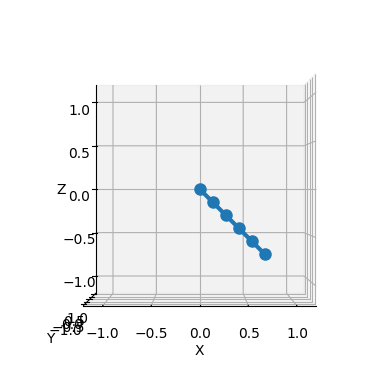

(<Figure size 640x480 with 1 Axes>,
 <Axes3D: xlabel='X', ylabel='Y', zlabel='Z'>)

In [7]:
chain_open.plot_initial_state("open")

This looks as expected! Next, simulation parameters may be set up.

In [8]:
#time stepping
dt = 0.005
end_time = 10
tspan = np.arange(0, end_time + dt/2, dt) # dt/2 to include end_time

#base movement. Velocity is set to zero, but A_base is set to simulate gravity.
V_base = np.zeros(6)
A_base = np.zeros(6)
A_base[-1] = 9.81 #simulating gravity

With the parameters for simulation set up, it is ready to run. This is done below:

In [15]:
chain_open.simulate(tspan,V_base,A_base,"open")

Simulation started (open-loop configuration)
Simulation finished. Runtime: 5.67 s


Simulation is finished. To see the pendulum in action, the animation function is used. This runs a lot better in standalone scripts, as Jupyer Notebook has problems rendering animations in line. To compensate for this, the video should pop up instead.


In [ ]:
%matplotlib tk
ani = chain_open.animation(config="open",step=5)


In [32]:
%matplotlib inline

The generalized velocities can now be plotted! The energy drift aswell. Please do note that these plots do not have the same nice formatting as in the main document. These plots are created seperately using CSV files and nicer functions found in results_plotting.py

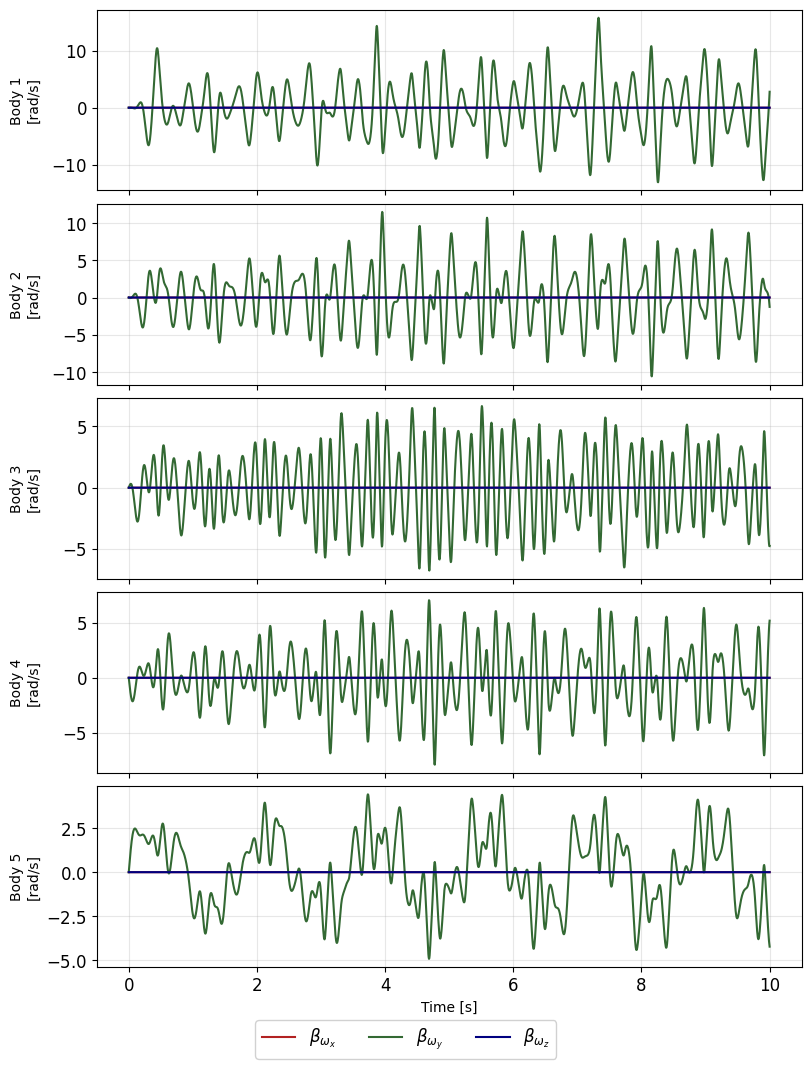

In [ ]:
chain_open.plot_gen_velocities()

TE_error calculated!


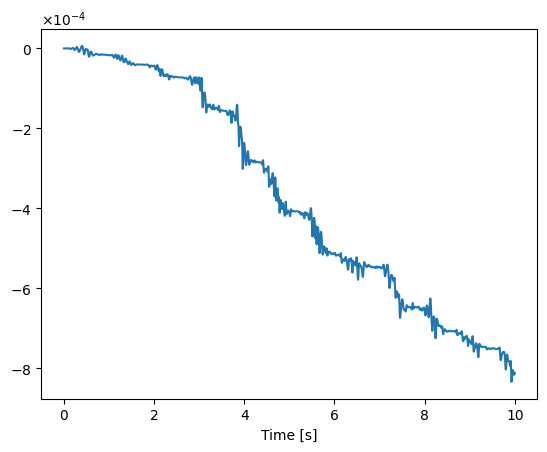

In [34]:
chain_open.calc_TE_error()
chain_open.plot_attribute("TE_error")

# Example 2: 3 link closed pendulum.
The following examples outlines basis of the simulation done in section 5 of the main document. It expands upon example 1 by closing the chain.

The set up follows the procedure from example 1. It is important, that the initial configuration is a valid closed loop.

In [1]:
#clearing variables and reimporting libaries
%reset -f
import numpy as np
from utils import objects as ob
from utils import soa as SOA
import matplotlib.pyplot as plt


In [2]:
#Initializing MultBodySystem
chain_closed = ob.MultiBodySystem()

joint3 = ob.SphericalJoint()
joint2 = ob.SphericalJoint()
joint1 = ob.SphericalJoint()


#intialziing such that pendulum is hanging to the right and forms a closed triangle
joint3.q_init = SOA.quatfromrev(0.5*np.pi, "y")
joint2.q_init = SOA.quatfromrev(2*np.pi/3, "y")
joint1.q_init = SOA.quatfromrev(2*np.pi/3, "y")

#defining links
m = 20 #kg
l_hinge = np.array([0,0,0.2]) #m

link3= ob.Link(mass=m, l_hinge=l_hinge, joint=joint3)
link2 = ob.Link(mass=m, l_hinge=l_hinge, joint=joint2)
link1 = ob.Link(mass=m, l_hinge=l_hinge, joint=joint1)


#adding links 
chain_closed.add_link(link3)
chain_closed.add_link(link2)
chain_closed.add_link(link1)

Once again, the initial configuration may be checked to see if it is valid.

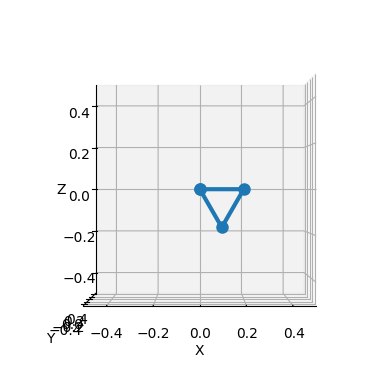

(<Figure size 640x480 with 1 Axes>,
 <Axes3D: xlabel='X', ylabel='Y', zlabel='Z'>)

In [3]:
chain_closed.plot_initial_state("closed")

It is a closed triangle as expected. The simulation parameters are set up as they were in example 1 and a simulation is run. Note that since the simulation is now closed, Baumgarte parameters are needed.

In [4]:
#parameters for simulation
dt = 0.005
end_time = 10
tspan = np.arange(0, end_time + dt/2, dt) # dt/2 to include end_time

V_base = np.zeros(6)
A_base = np.zeros(6)
A_base[-1] = 9.81 
BG_params = [0.1,500]

chain_closed.simulate(tspan,V_base,A_base,"closed",BG_params=BG_params)

Simulation started (closed-loop configuration)
Simulation finished. Runtime: 11.83 s


To see it in action, the animation function is once again used.

In [5]:
%matplotlib tk
ani = chain_closed.animation(config="closed",step=5)

In [7]:
%matplotlib inline

Generalized velocities, energy error and constraint violation may also be plotted.

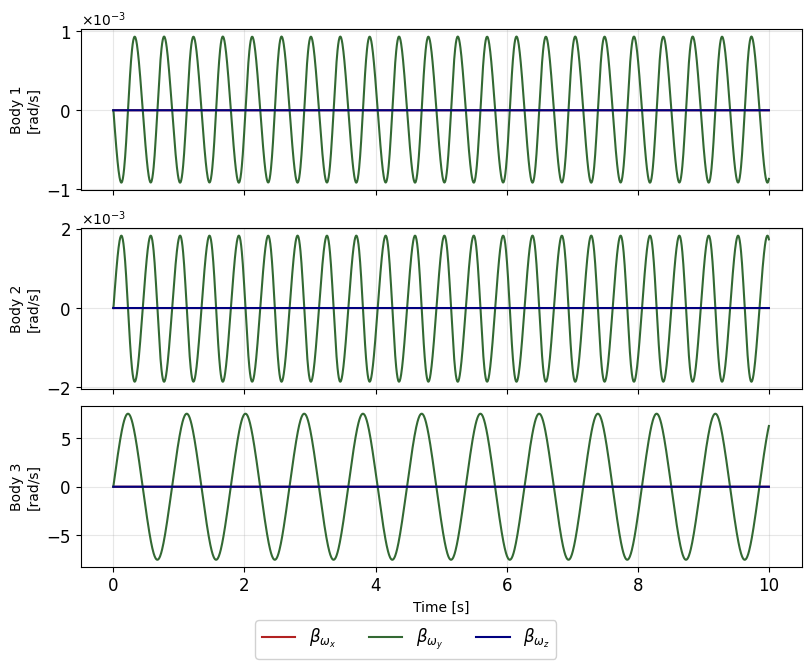

In [8]:
chain_closed.plot_gen_velocities()

TE_error calculated!


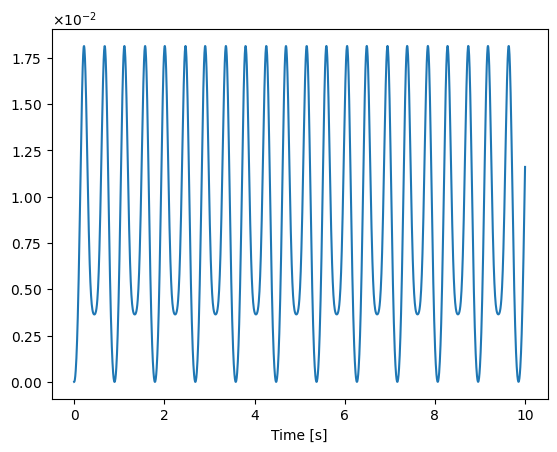

In [9]:
chain_closed.calc_TE_error()
chain_closed.plot_attribute("TE_error")

Text(0.5, 0, 'time [s]')

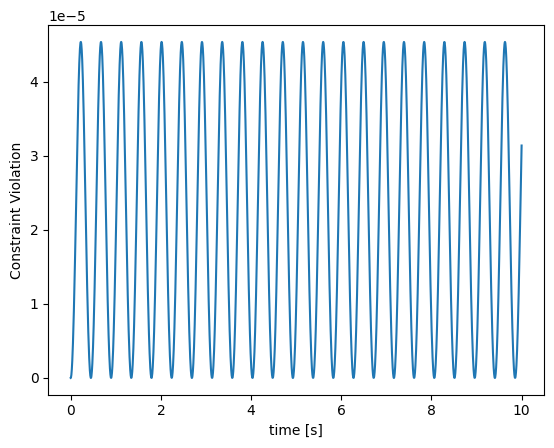

In [11]:
plt.plot(tspan,chain_closed.constraint_violation)
plt.ylabel("Constraint Violation")
plt.xlabel("time [s]")

# Example 3: Additional constraints
This example follows section 6 of the main document. The setup procedure is the same as the previous two examples. The free hinge is utilized here.

In [1]:
#clearing variables and reimporting libaries
%reset -f
import numpy as np
from utils import objects as ob
from utils import soa as SOA

The general multibody set up is shown below:

In [2]:
#intializing multibodysystem
chain_mult_const = ob.MultiBodySystem()

#defining joints
joint3 = ob.FreeJoint()
joint2 = ob.SphericalJoint()
joint1 = ob.SphericalJoint()

#intialziing such that pendulum is hanging to the right. This requires a H stack, as the free joint also takes an intitial position
joint3.q_init = np.hstack([SOA.quatfromrev(np.pi/2, "y"),np.array([0.0,0.0,0.0])])
joint2.q_init = SOA.quatfromrev(2*np.pi/3, "y")
joint1.q_init = SOA.quatfromrev(2*np.pi/3, "y")

#defining link
m = 20 #kg
l_hinge = np.array([0,0,0.2])

link3 = ob.Link(mass=m, l_hinge=l_hinge, joint=joint3)
link2 = ob.Link(mass=m, l_hinge=l_hinge, joint=joint2)
link1 = ob.Link(mass=m, l_hinge=l_hinge, joint=joint1)

#adding links
chain_mult_const.add_link(link3)
chain_mult_const.add_link(link2)
chain_mult_const.add_link(link1)

Simulation parameters are set up and the chain is simulated. It is then animated.

In [3]:
#parameters for simulation
dt = 0.005
end_time = 10
tspan = np.arange(0, end_time + dt/2, dt) # dt/2 to include end_time

V_base = np.zeros(6)
A_base = np.zeros(6)
A_base[-1] = 9.81 
BG_params = [100,200]

chain_mult_const.simulate(tspan,V_base,A_base,"multiple_constraints",BG_params=BG_params)

Simulation started (multiple_constraints-loop configuration)
Simulation finished. Runtime: 14.29 s


In [4]:
%matplotlib tk
ani = chain_mult_const.animation(config="closed",step=5)

# Example 4: Chain wrapped around sprockets using the penalty method
To see the example, please run the standalone sprocket_belt.py file. This simulation is a bit longer than the others, so for convenience the resulting video can be found under Videos.